## Proyecto Final - Telecomunicaciones 

Enlace presentación PDF resultados: https://drive.google.com/file/d/1_EaJLKYzKO5Ql39XdXGRhFsbf3jYbXMJ/view?usp=sharing

### 1. Introducción 

El objetivo de este análisis es realizar un estudio sobre el rendimiento de los operadores de la empresa CallMeMaybe para identificar aquellos que sean menos eficaces. Se considera a un operador ineficaz cuando: 
- Tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes.
- Un número reducido de llamadas salientes.

La idea es identificar aquellos operadores con el fin de supervisores y supervisoras tengan esta información y puedan tomar decisiones adecuadas al respecto. 

### 2. Importar librerías y cargar datos 

In [87]:
#carga de librerías
from scipy import stats as st
import pandas as pd 
import matplotlib.pyplot as plt

In [88]:
#leer datos 
clients = pd.read_csv('telecom_clients_us.csv')
operators = pd.read_csv('telecom_dataset_us.csv')

### 3. Limpieza de datos 

#### Clients 

In [89]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [90]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


Se debe transformar la columna user_id a object y la columna date_start a formato datetime. No se tiene valores nulos. 

In [91]:
#se realiza la tranformacion de datos a los tipos correctos y se verifica.
clients['user_id'] = clients['user_id'].astype ('object')
clients['date_start'] = pd.to_datetime(clients['date_start'])
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    object        
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 17.3+ KB


In [92]:
#se verifica duplicados 
clients.duplicated().sum()

np.int64(0)

No se presentan registros duplicados. 

#### Operators

In [93]:
operators.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [94]:
operators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


Se debe transformar la columna user_id a object, date a datetime y sacar una nueva columna solo con la fecha, operator_id tambien transformar a object. Seguido se debe analizar los valores nulos en operator_id y missed_call para ver comomanejarlos. 

In [95]:
#se realiza la tranformacion de datos a los tipos correctos y se verifica.
operators['user_id'] = operators['user_id'].astype ('object')
operators['date'] = pd.to_datetime(operators['date'])
operators['operator_id'] = operators['operator_id'].astype('object')
operators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  object                   
 1   date                 53902 non-null  datetime64[ns, UTC+03:00]
 2   direction            53902 non-null  object                   
 3   internal             53785 non-null  object                   
 4   operator_id          45730 non-null  object                   
 5   is_missed_call       53902 non-null  bool                     
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
dtypes: bool(1), datetime64[ns, UTC+03:00](1), int64(3), object(4)
memory usage: 3.3+ MB


In [96]:
#se saca una nueva columna solo con la fecha para date
operators['date_final'] = operators['date'].dt.date
operators.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,date_final
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4,2019-08-04
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,2019-08-05
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,2019-08-05
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,2019-08-05
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,2019-08-05


In [97]:
#se analiza los valores nulos 
operators.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
date_final                0
dtype: int64

In [98]:
#se analiza los registros duplicados
duplicates = operators[operators.duplicated()]
duplicates

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,date_final
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50,2019-08-05
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34,2019-08-12
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.0,False,10,1567,1654,2019-08-14
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3,2019-08-14
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.0,False,11,1413,1473,2019-08-15
...,...,...,...,...,...,...,...,...,...,...
53869,168601,2019-11-25 00:00:00+03:00,in,False,952914.0,False,7,1229,1282,2019-11-25
53874,168601,2019-11-26 00:00:00+03:00,in,False,952914.0,False,4,539,562,2019-11-26
53875,168601,2019-11-26 00:00:00+03:00,in,False,NaN,True,3,0,35,2019-11-26
53885,168603,2019-11-20 00:00:00+03:00,out,False,959118.0,True,3,0,89,2019-11-20


In [99]:
duplicates_exact = operators[operators.duplicated(keep=False)]
print(duplicates_exact)

      user_id                      date direction internal operator_id  \
6      166377 2019-08-05 00:00:00+03:00       out    False    880020.0   
8      166377 2019-08-05 00:00:00+03:00       out    False    880020.0   
27     166377 2019-08-12 00:00:00+03:00        in    False         NaN   
28     166377 2019-08-12 00:00:00+03:00        in    False         NaN   
38     166377 2019-08-14 00:00:00+03:00        in    False         NaN   
...       ...                       ...       ...      ...         ...   
53875  168601 2019-11-26 00:00:00+03:00        in    False         NaN   
53883  168603 2019-11-20 00:00:00+03:00       out    False    959118.0   
53885  168603 2019-11-20 00:00:00+03:00       out    False    959118.0   
53899  168606 2019-11-15 00:00:00+03:00       out     True    957922.0   
53900  168606 2019-11-15 00:00:00+03:00       out     True    957922.0   

       is_missed_call  calls_count  call_duration  total_call_duration  \
6                True            8   

Se verifica que los duplicados son un error al momento de la toma de datos ya que no se presenta ninguna razón para que existan registros duplicados, se procede a eliminar estos registros duplicados para no afectar al análisis de los datos. 

In [100]:
operators = operators.drop_duplicates()
operators.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49002 entries, 0 to 53901
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              49002 non-null  object                   
 1   date                 49002 non-null  datetime64[ns, UTC+03:00]
 2   direction            49002 non-null  object                   
 3   internal             48892 non-null  object                   
 4   operator_id          41546 non-null  object                   
 5   is_missed_call       49002 non-null  bool                     
 6   calls_count          49002 non-null  int64                    
 7   call_duration        49002 non-null  int64                    
 8   total_call_duration  49002 non-null  int64                    
 9   date_final           49002 non-null  object                   
dtypes: bool(1), datetime64[ns, UTC+03:00](1), int64(3), object(5)
memory usage:

In [101]:
#verificar nulos 
operators.isna().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
date_final                0
dtype: int64

Se puede ver que se siguen mateniendo valores nulos a pesar de que se redujeron un poco.

In [102]:
#se analiza valoes nulos en operator_id y su relación con llamadas perdidas
operators[(operators['operator_id'].isna()) & (operators['is_missed_call'] == True)]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,date_final
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4,2019-08-04
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35,2019-08-05
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62,2019-08-06
17,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24,2019-08-07
27,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34,2019-08-12
...,...,...,...,...,...,...,...,...,...,...
53876,168601,2019-11-27 00:00:00+03:00,in,False,NaN,True,2,0,39,2019-11-27
53880,168601,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,19,2019-11-28
53889,168603,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,30,2019-11-28
53893,168606,2019-11-08 00:00:00+03:00,in,False,NaN,True,6,0,121,2019-11-08


In [103]:
#se analiza valores nulos en internal
operators[operators['internal'].isna()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,date_final
1007,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59,2019-09-18
1090,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1,2019-10-01
1864,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36,2019-08-20
1924,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.0,False,1,2,9,2019-09-02
6210,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.0,False,1,393,423,2019-09-26
...,...,...,...,...,...,...,...,...,...,...
52462,168361,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,6,0,14,2019-11-09
52590,168361,2019-11-13 00:00:00+03:00,in,NaN,NaN,True,2,0,6,2019-11-13
52621,168361,2019-11-14 00:00:00+03:00,in,NaN,NaN,True,1,0,2,2019-11-14
53717,168579,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,1,0,18,2019-11-09


Se puede ver que la gran mayoría de casos en los que no se tienen un registro para operator_id vienen a ser llamadas perdidas. Después de analizar los valores nulos tanto en internal como en operator_id se ha decidido que no se van a eliminar estos registros ya que si se cuenta con otros datos importantes para el análisis. Simplemente se los excluirá cuando se requiera hacer análisis con esas columnas para que no se presenten problemas en los mismos. 

#### 4. Análisis Exploratorio

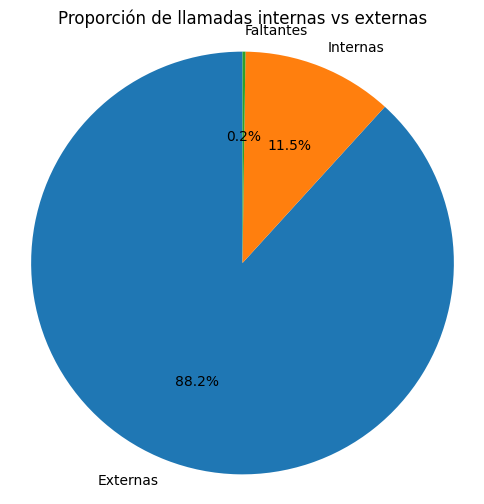

In [104]:
#se identifica el porcentaje de llamadas externas e internas con un pie chart.
internal_external = operators['internal'].value_counts(dropna=False)
labels = ['Externas', 'Internas', 'Faltantes']
plt.figure(figsize=(6, 6))
plt.pie(internal_external, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Proporción de llamadas internas vs externas')
plt.axis('equal')
plt.show()

El 88% de las llamadas registradas son externas, tan solo el 0.2% de llamadas no tienen un registro. 

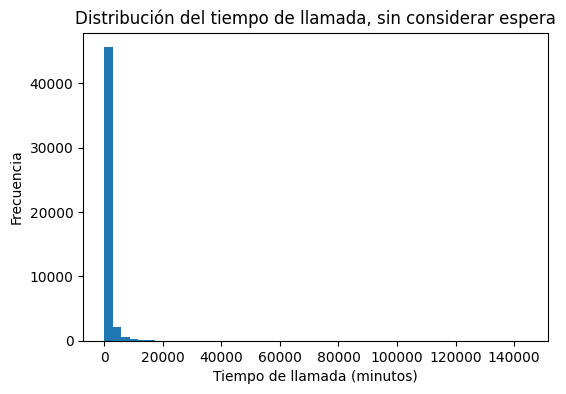

In [105]:
#Se observa la distribución de tiempo de llamadas sin considerar tiempo de espera
plt.figure(figsize=(6, 4))
plt.hist(operators['call_duration'], bins=50)
plt.title('Distribución del tiempo de llamada, sin considerar espera')
plt.xlabel('Tiempo de llamada (minutos)')
plt.ylabel('Frecuencia')
plt.show()

La gran mayoría de llamadas tienen una duración normal de tiempo de llamada.

In [106]:
#se agrupa por usuario para calcular la tasa de llamadas perdidas y el tiempo de espera promedio.
grouped_operators = operators.groupby('operator_id').agg(llamadas_perdidas = ('is_missed_call', 'sum'), 
                                               total_llamadas = ('calls_count', 'sum'), 
                                               tiempo_espera_promedio = ('total_call_duration', lambda x: 
                                                                         (x - operators['call_duration']).mean())).reset_index() 

grouped_operators['tasa_llamadas_perdidas'] = grouped_operators['llamadas_perdidas'] / grouped_operators['total_llamadas']

grouped_operators.sort_values(by = ['tasa_llamadas_perdidas', 'tiempo_espera_promedio'], ascending= False)

,operator_id,llamadas_perdidas,total_llamadas,tiempo_espera_promedio,tasa_llamadas_perdidas
617,932246.0,1,1,60.000000,1.0
697,937770.0,1,1,37.000000,1.0
160,899076.0,2,2,23.500000,1.0
688,937716.0,1,1,19.000000,1.0
700,937778.0,1,1,19.000000,1.0
...,...,...,...,...,...
871,946020.0,0,1,3.000000,0.0
1027,960666.0,0,1,3.000000,0.0
961,952982.0,0,8,1.166667,0.0
911,948282.0,0,1,1.000000,0.0


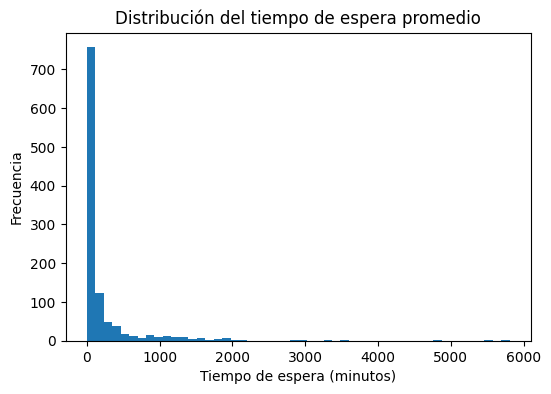

In [113]:
#Se observa la distribución de tiempo de espera promedio
plt.figure(figsize=(6, 4))
plt.hist(grouped_operators['tiempo_espera_promedio'], bins=50)
plt.title('Distribución del tiempo de espera promedio')
plt.xlabel('Tiempo de espera (minutos)')
plt.ylabel('Frecuencia')
plt.show()

Se puede ver que hay tiempos de espera de hasta 60 minutos, pero la mayoría tienen una espera menor a los 5 minutos.

Se puede observar en la tabla grouped operators que aquellos operadores que tienen una tasa de llamadas perdidas de 1 son aquellos que tienen entre 1 y 2 llamadas en total, lo cual no es un dato significativo. Por esto se va a filtrar a los operadores que han tenido al menos 10 llamadas para identidicar su tasa de llamadas persdidas reales. 

In [115]:
#se filtra por operadores con mas de 10 llamadas y se ordena para identificar ineficientes
operators_more_10calls = grouped_operators [grouped_operators['total_llamadas']>10]
inefficient_operators = operators_more_10calls.sort_values(by = ['tasa_llamadas_perdidas', 'tiempo_espera_promedio'], ascending= False)
inefficient_operators.head(10)

,operator_id,llamadas_perdidas,total_llamadas,tiempo_espera_promedio,tasa_llamadas_perdidas
40,888406.0,6,15,25.230769,0.400000
113,894232.0,8,20,23.846154,0.400000
639,933996.0,6,15,15.666667,0.400000
792,940788.0,4,11,27.142857,0.363636
419,918888.0,4,11,10.363636,0.363636
7,881278.0,7,20,9.750000,0.350000
95,892530.0,6,18,38.333333,0.333333
112,894230.0,7,21,20.416667,0.333333
742,939212.0,5,17,14.071429,0.294118
111,894226.0,7,24,31.090909,0.291667


Los operadores con más de 10 llamadas que a simple vista se puede decir que son los más ineficientes presentan una tasa de llamadas perdidas del 40%, lo cual viene a ser un porcentaje alto para el rendimiento de un operador que se dedica por completo a manejar llamadas.

In [109]:
#se analiza la cantidad de llamadas salientes que tienen el operador 
llamadas_salientes = operators[operators['direction'] == 'out']

cantidad_salientes = llamadas_salientes.groupby('operator_id').agg(
    total_llamadas_salientes = ('calls_count', 'sum')).reset_index()

#se agrupa con la tabla anterior creada para tener todas las estadisticas en un solo lugar
rendimiento_operadores = pd.merge(cantidad_salientes, grouped_operators, on = 'operator_id', how = 'left')

#se calcula el porcentaje de llamadas salientes respecto al total de llamadas
rendimiento_operadores['tasa_llamadas_salientes'] = rendimiento_operadores['total_llamadas_salientes'] / rendimiento_operadores ['total_llamadas']
rendimiento_operadores.head(10)


,operator_id,total_llamadas_salientes,llamadas_perdidas,total_llamadas,tiempo_espera_promedio,tasa_llamadas_perdidas,tasa_llamadas_salientes
0,879896.0,872,47,930,104.914530,0.050538,0.937634
1,879898.0,7209,89,7313,457.696035,0.012170,0.985779
2,880020.0,38,6,45,14.000000,0.133333,0.844444
3,880022.0,189,29,197,53.971429,0.147208,0.959391
4,880026.0,2208,87,2232,121.978022,0.038978,0.989247
5,880028.0,2497,82,2560,210.178218,0.032031,0.975391
6,880240.0,47,7,47,47.333333,0.148936,1.000000
7,881278.0,20,7,20,9.750000,0.350000,1.000000
8,882478.0,1,1,4,27.666667,0.250000,0.250000
9,882684.0,661,54,1274,128.480519,0.042386,0.518838


Una vez calculadas todas las estadísticas se contiúa con el análisis de hipótesis para identificar si existe una diferencia significativa entre los indicadores de los operadores eficientes e ineficientes identificados. 

In [119]:
#ordenar por tasa de llamadas salientes para ver las mas bajas
rendimiento_ineficiente = rendimiento_operadores.sort_values(by = ['tasa_llamadas_salientes', 'total_llamadas'], ascending= [True, False])
rendimiento_ineficiente.head(10)

,operator_id,total_llamadas_salientes,llamadas_perdidas,total_llamadas,tiempo_espera_promedio,tasa_llamadas_perdidas,tasa_llamadas_salientes
350,919206.0,1,7,927,369.450000,0.007551,0.001079
577,937956.0,1,9,774,17.150000,0.011628,0.001292
349,919204.0,9,8,1176,394.041667,0.006803,0.007653
376,919554.0,11,14,1193,456.642857,0.011735,0.009220
210,905862.0,1,4,103,30.657895,0.038835,0.009709
377,919790.0,23,4,1601,717.945946,0.002498,0.014366
339,919164.0,10,7,658,188.954545,0.010638,0.015198
379,919794.0,21,2,1157,773.404762,0.001729,0.018150
340,919166.0,20,6,1013,245.416667,0.005923,0.019743
261,909134.0,5,6,202,99.442857,0.029703,0.024752


Se pueden ver todos los operadores con un alto núnermo de llamadas totales y una tasa muy baja de llamadas salientes, razón por la cual también es consideran operadores ineficiente. 

#### 5. Prueba de Hipótesis 

Las hipótesis a comprobar son las siguientes: 

- Hipótesis 1: Comparación del tiempo de espera promedio en llamadas entre operadores con alta y baja tasa de llamadas perdidas. 
    - H0:  No hay diferencia significativa en el tiempo de espera promedio entre los dos grupos.
    - Ha: Hay una diferencia significativa en el tiempo de espera promedio.

- Hipótesis 2: Comparación de la tasa de llamadas perdidas entre operadores con alta y baja actividad de llamadas salientes
    - H0: No hay diferencia significativa en la tasa de llamadas perdidas entre los dos grupos.
    - Ha: Hay una diferencia significativa en la tasa de llamadas perdidas. 

In [110]:
#se crean 2 grupos para las pruebas de hipótesis, se usa la medina como indicador para separar los 2 grupos
media_llamadas_perdidas = grouped_operators['tasa_llamadas_perdidas'].median()
altas_llamadas_perdidas = grouped_operators[grouped_operators['tasa_llamadas_perdidas'] > media_llamadas_perdidas]
bajas_llamadas_perdidas = grouped_operators[grouped_operators['tasa_llamadas_perdidas'] <= media_llamadas_perdidas]

#grupos finales para hipotesis 1 tiempos de espera
alto_tiempo_espera = altas_llamadas_perdidas['tiempo_espera_promedio'].dropna()
bajo_tiempo_espera = bajas_llamadas_perdidas['tiempo_espera_promedio'].dropna()

#grupos para hipotesis 2 basado en llamadas salientes 
media_llamadas_salientes = rendimiento_operadores['tasa_llamadas_salientes'].median()
altas_llamadas_salientes = rendimiento_operadores[rendimiento_operadores['tasa_llamadas_salientes'] > media_llamadas_salientes]
bajas_llamadas_salientes = rendimiento_operadores[rendimiento_operadores['tasa_llamadas_salientes'] <= media_llamadas_salientes]

#grupos finales para hipotesis 2 llamadas perdidas
llamadas_perdidas_altas_salientes = altas_llamadas_salientes['tasa_llamadas_perdidas'].dropna()
llamadas_perdidas_bajas_salientes = bajas_llamadas_salientes['tasa_llamadas_perdidas'].dropna()


In [111]:
#se define una función para probar igualdad de varianza y normalidad 
def validaciones(grupo1, grupo2, alpha=0.05):
    
    # Prueba de normalidad 
    shapiro_grupo1 = st.shapiro(grupo1)
    shapiro_grupo2 = st.shapiro(grupo2)

    # Prueba de igualdad de varianzas
    prueba_levene = st.levene(grupo1, grupo2)

    # Mensajes de interpretación
    print("\n **Resultados de Validaciones**")
    
    # Normalidad
    if shapiro_grupo1.pvalue < alpha:
        print(f" Grupo 1 NO sigue una distribución normal (p = {shapiro_grupo1.pvalue})")
    else:
        print(f" Grupo 1 sigue una distribución normal (p = {shapiro_grupo1.pvalue})")
    
    if shapiro_grupo2.pvalue < alpha:
        print(f" Grupo 2 NO sigue una distribución normal (p = {shapiro_grupo2.pvalue})")
    else:
        print(f" Grupo 2 sigue una distribución normal (p = {shapiro_grupo2.pvalue})")
    
    # Igualdad de varianzas
    if prueba_levene.pvalue < alpha:
        print(f" Las varianzas NO son iguales (p = {prueba_levene.pvalue})")
    else:
        print(f" Las varianzas son iguales (p = {prueba_levene.pvalue})")

    return {
        "shapiro_grupo1": shapiro_grupo1,
        "shapiro_grupo2": shapiro_grupo2,
        "prueba_levene": prueba_levene
    }

# Aplicar la función a los dos conjuntos de datos
print("\n **Comparación de Tiempo de Espera (Alto vs Bajo)**")
tiempo_espera = validaciones(alto_tiempo_espera, bajo_tiempo_espera)

print("\n **Comparación de Llamadas Perdidas (Altas vs Bajas llamadas salientes)**")
llamadas_perdidas = validaciones(llamadas_perdidas_altas_salientes, llamadas_perdidas_bajas_salientes)


 **Comparación de Tiempo de Espera (Alto vs Bajo)**

 **Resultados de Validaciones**
 Grupo 1 NO sigue una distribución normal (p = 3.56578260692465e-24)
 Grupo 2 NO sigue una distribución normal (p = 1.1470987009737238e-34)
 Las varianzas NO son iguales (p = 5.1200308314092784e-30)

 **Comparación de Llamadas Perdidas (Altas vs Bajas llamadas salientes)**

 **Resultados de Validaciones**
 Grupo 1 NO sigue una distribución normal (p = 1.970372872837558e-30)
 Grupo 2 NO sigue una distribución normal (p = 4.582430049957326e-22)
 Las varianzas NO son iguales (p = 1.868604784026537e-08)


Después de analizar la prueba de normalidad e igualdad de varianzas para todos los grupos, se concluye que ningún grupo cuenta con una distribución normal ni presenta varianzas iguales. Al no tener distribuciones normales, se deben realizar pruebas de Mann-Whitney U para probar ambas hipótesis. 

In [112]:
#prueba de hipotesis con Mann-Whitney

alpha = 0.05 

# Prueba Mann-Whitney U para el tiempo de espera
resultados_hipotesis1 = st.mannwhitneyu(alto_tiempo_espera, bajo_tiempo_espera, alternative='two-sided')
decision1 = "Se rechaza la hipótesis nula, existe una diferencia significativa entre ambos grupos" if resultados_hipotesis1.pvalue < alpha else "No se rechaza la hipótesis nula"

# Prueba Mann-Whitney U para la tasa de llamadas perdidas
resultados_hipotesis2 = st.mannwhitneyu(llamadas_perdidas_altas_salientes, llamadas_perdidas_bajas_salientes, alternative='two-sided')
decision2 = "Se rechaza la hipótesis nula, existe una diferencia significativa entre ambos grupos" if resultados_hipotesis2.pvalue < alpha else "No se rechaza la hipótesis nula"

# Mostrar resultados
print(f"Hipótesis 1 - Tiempo de espera:\nU-Statistic: {resultados_hipotesis1.statistic:.2f}, p-value: {resultados_hipotesis1.pvalue:.4f}")
print(f"Decisión: {decision1}\n")

print(f"Hipótesis 2 - Tasa de llamadas perdidas:\nU-Statistic: {resultados_hipotesis2.statistic:.2f}, p-value: {resultados_hipotesis2.pvalue:.4f}")
print(f"Decisión: {decision2}")



Hipótesis 1 - Tiempo de espera:
U-Statistic: 87250.50, p-value: 0.0000
Decisión: Se rechaza la hipótesis nula, existe una diferencia significativa entre ambos grupos

Hipótesis 2 - Tasa de llamadas perdidas:
U-Statistic: 83057.00, p-value: 0.0002
Decisión: Se rechaza la hipótesis nula, existe una diferencia significativa entre ambos grupos


#### 5. Conclusiones 

Después de realizar ambas pruebas de hipótesis y obtener que se rechaza la hipótesis nula en ambos casos, se puede decir que si existe una diferencia estadísticamente significativa entre los 2 grupos que conforman cada hipótesis.

Esto significa que aquellos operadores que presentan un alto tiempo de espera con una alta tasa de llamadas perdidas pueden ser considerados como operadores ineficientes. 

De igual manera, aquellos operadores que presentan altas cantidades de llamadas perdidas con bajas llamadas salientes se consideran operadores ineficientes. 